<a href="https://colab.research.google.com/github/meghanagogineni2005-svg/data-science-python-internship/blob/main/Advanced_Data_Visualization_and_Storytelling_with_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
url = "https://ourworldindata.org/grapher/annual-co2-including-land-use.csv?v=1&csvType=full&useColumnShortNames=false"

df = pd.read_csv(
    url,
    storage_options={
        "User-Agent": "Our World in Data data fetch/1.0"
    }
)

df.head()

,Entity,Code,Year,Annual CO₂ emissions including land-use change
0,Afghanistan,AFG,1949,6116828.0
1,Afghanistan,AFG,1950,7169019.0
2,Afghanistan,AFG,1951,8092017.5
3,Afghanistan,AFG,1952,9005343.0
4,Afghanistan,AFG,1953,10070064.0


In [4]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

Dataset shape: (23796, 4)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23796 entries, 0 to 23795
Data columns (total 4 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Entity                                          23796 non-null  object 
 1   Code                                            22927 non-null  object 
 2   Year                                            23796 non-null  int64  
 3   Annual CO₂ emissions including land-use change  23796 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 743.8+ KB


In [5]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Entity                                              0
Code                                              869
Year                                                0
Annual CO₂ emissions including land-use change      0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [7]:
print("Year range:", df["Year"].min(), "to", df["Year"].max())
print("Number of unique entities:", df["Entity"].nunique())

Year range: 1850 to 2024
Number of unique entities: 211


In [8]:
df_clean = df.copy()

# Fill missing country/region codes with "N/A"
df_clean["Code"] = df_clean["Code"].fillna("N/A")

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Entity                                            0
Code                                              0
Year                                              0
Annual CO₂ emissions including land-use change    0
dtype: int64


In [9]:
df_clean.head()

,Entity,Code,Year,Annual CO₂ emissions including land-use change
0,Afghanistan,AFG,1949,6116828.0
1,Afghanistan,AFG,1950,7169019.0
2,Afghanistan,AFG,1951,8092017.5
3,Afghanistan,AFG,1952,9005343.0
4,Afghanistan,AFG,1953,10070064.0


In [10]:
df_clean[df_clean["Entity"].str.contains("World", case=False, na=False)]["Entity"].unique()

array(['World'], dtype=object)

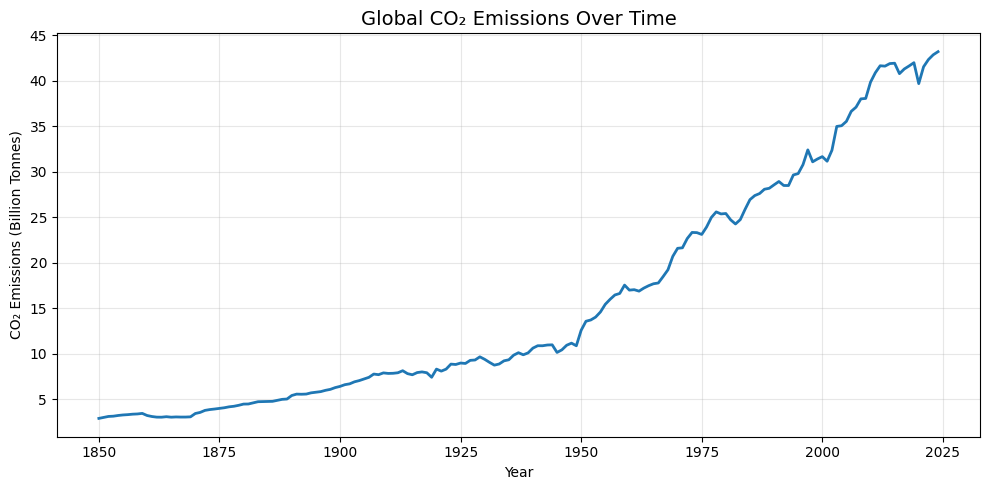

In [12]:
world = df_clean[df_clean["Entity"] == "World"].copy()

# Convert emissions from tonnes to billion tonnes
world["CO2_Billion_Tonnes"] = (
    world["Annual CO₂ emissions including land-use change"] / 1e9
)

plt.figure(figsize=(10, 5))

plt.plot(
    world["Year"],
    world["CO2_Billion_Tonnes"],
    linewidth=2
)

plt.title("Global CO₂ Emissions Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Billion Tonnes)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Select data for the year 2024
data_2024 = df_clean[df_clean["Year"] == 2024].copy()

# Remove aggregate regions and keep countries only
aggregate_entities = [
    "World",
    "Asia",
    "Africa",
    "Europe",
    "North America",
    "South America",
    "Oceania",
    "European Union (27)",
    "European Union (28)",
    "High-income countries",
    "Upper-middle-income countries",
    "Lower-middle-income countries",
    "Low-income countries",
    "Asia (excl. China and India)",
    "Europe (excl. EU-27)",
    "Europe (excl. EU-28)",
    "North America (excl. USA)"
]

countries_2024 = data_2024[
    ~data_2024["Entity"].isin(aggregate_entities)
].copy()

# Select top 10 countries
top10 = countries_2024.sort_values(
    by="Annual CO₂ emissions including land-use change",
    ascending=False
).head(10)

top10

,Entity,Code,Year,Annual CO₂ emissions including land-use change
4389,China,CHN,2024,1.196962e+10
22488,United States,USA,2024,5.016179e+09
10334,India,IND,2024,3.201024e+09
18026,Russia,RUS,2024,2.166402e+09
3165,Brazil,BRA,2024,2.082678e+09
10470,Indonesia,IDN,2024,1.388412e+09
11289,Japan,JPN,2024,9.673613e+08
10585,Iran,IRN,2024,8.168910e+08
18564,Saudi Arabia,SAU,2024,6.926054e+08
5628,Democratic Republic of Congo,COD,2024,6.541006e+08


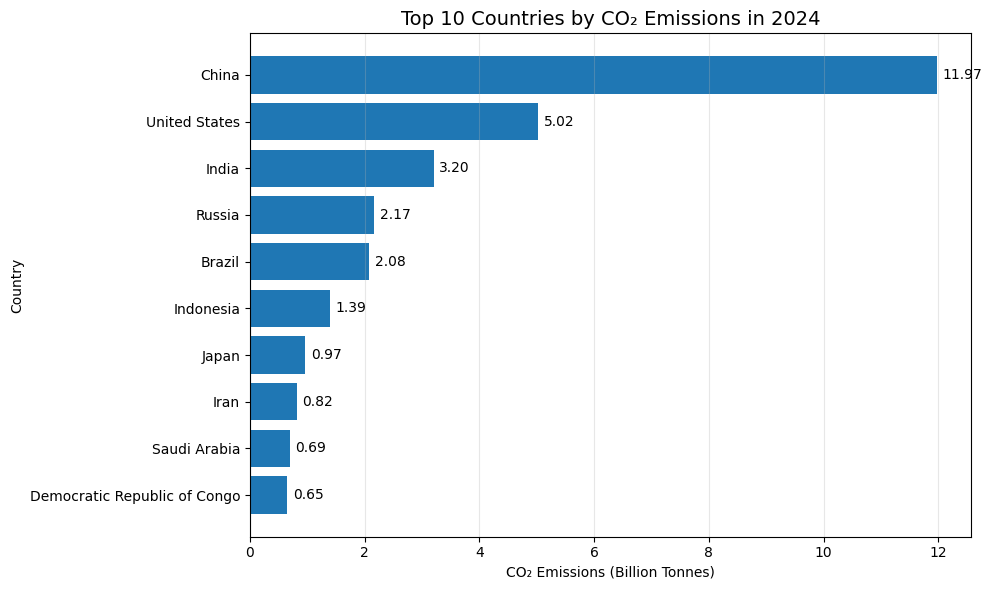

In [15]:
plt.figure(figsize=(10, 6))

values = top10["Annual CO₂ emissions including land-use change"] / 1e9

bars = plt.barh(
    top10["Entity"],
    values
)

plt.title("Top 10 Countries by CO₂ Emissions in 2024", fontsize=14)
plt.xlabel("CO₂ Emissions (Billion Tonnes)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

# Add values at the end of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

In [16]:
# Check the column names in our dataset
print(df_clean.columns.tolist())

['Entity', 'Code', 'Year', 'Annual CO₂ emissions including land-use change']


In [18]:
per_capita_url = "https://ourworldindata.org/grapher/per-capita-co2-including-land.csv?v=1&csvType=full&useColumnShortNames=false"

df_per_capita = pd.read_csv(
    per_capita_url,
    storage_options={
        "User-Agent": "Our World in Data data fetch/1.0"
    }
)

df_per_capita.head()

,Entity,Code,Year,Annual CO₂ emissions including land-use change per capita
0,Afghanistan,AFG,1949,0.831442
1,Afghanistan,AFG,1950,0.921920
2,Afghanistan,AFG,1951,1.026991
3,Afghanistan,AFG,1952,1.127389
4,Afghanistan,AFG,1953,1.243724


In [19]:
print("Dataset shape:", df_per_capita.shape)
print(df_per_capita.columns.tolist())
print("Year range:", df_per_capita["Year"].min(), "to", df_per_capita["Year"].max())

Dataset shape: (23757, 4)
['Entity', 'Code', 'Year', 'Annual CO₂ emissions including land-use change per capita']
Year range: 1850 to 2024


In [20]:
per_capita_2024 = df_per_capita[
    df_per_capita["Year"] == 2024
].copy()

print(per_capita_2024.shape)
per_capita_2024.head()

(211, 4)


,Entity,Code,Year,Annual CO₂ emissions including land-use change per capita
75,Afghanistan,AFG,2024,0.681722
216,Africa,OWID_AFR,2024,2.197543
308,Albania,ALB,2024,1.441533
417,Algeria,DZA,2024,4.288056
452,Andorra,AND,2024,5.108788


In [21]:
# Remove aggregate regions
aggregate_entities = [
    "World",
    "Asia",
    "Africa",
    "Europe",
    "North America",
    "South America",
    "Oceania",
    "European Union (27)",
    "European Union (28)",
    "High-income countries",
    "Upper-middle-income countries",
    "Lower-middle-income countries",
    "Low-income countries"
]

countries_per_capita = per_capita_2024[
    ~per_capita_2024["Entity"].isin(aggregate_entities)
].copy()

# Select top 10 countries
top10_per_capita = countries_per_capita.sort_values(
    by="Annual CO₂ emissions including land-use change per capita",
    ascending=False
).head(10)

top10_per_capita

,Entity,Code,Year,Annual CO₂ emissions including land-use change per capita
17651,Qatar,QAT,2024,41.278580
3257,Brunei,BRN,2024,27.864527
11712,Kuwait,KWT,2024,26.249542
1964,Bahrain,BHR,2024,24.270105
21328,Trinidad and Tobago,TTO,2024,22.822807
18525,Saudi Arabia,SAU,2024,20.393090
22099,United Arab Emirates,ARE,2024,20.131084
2548,Belize,BLZ,2024,17.198261
3871,Canada,CAN,2024,16.236720
1453,Australia,AUS,2024,16.036572


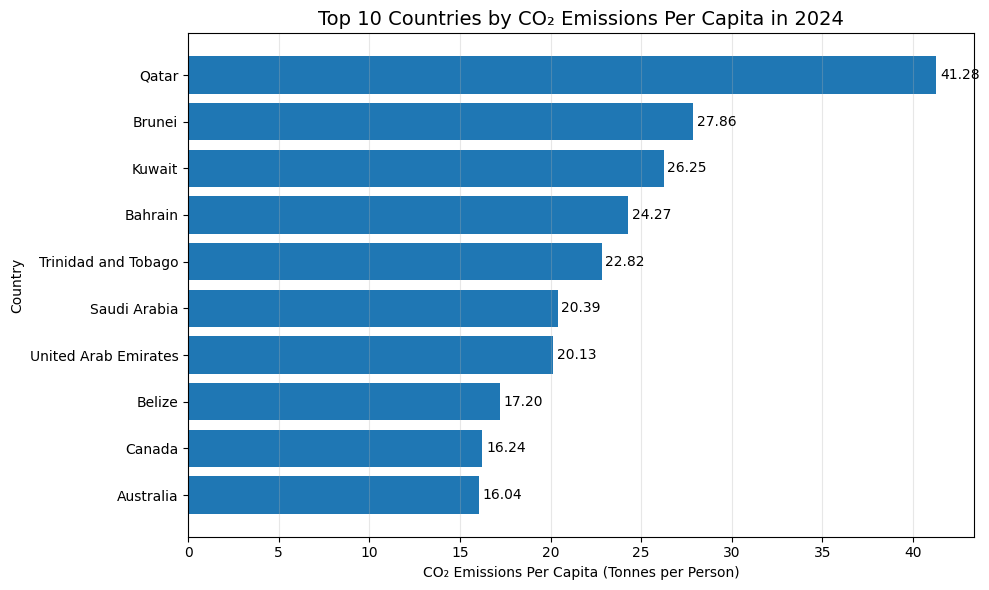

In [22]:
plt.figure(figsize=(10, 6))

values = top10_per_capita[
    "Annual CO₂ emissions including land-use change per capita"
]

bars = plt.barh(
    top10_per_capita["Entity"],
    values
)

plt.title(
    "Top 10 Countries by CO₂ Emissions Per Capita in 2024",
    fontsize=14
)

plt.xlabel("CO₂ Emissions Per Capita (Tonnes per Person)")
plt.ylabel("Country")

plt.gca().invert_yaxis()

# Add values at the end of each bar
for bar, value in zip(bars, values):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.show()

In [23]:
gdp_url = "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=false"

df_gdp = pd.read_csv(
    gdp_url,
    storage_options={
        "User-Agent": "Our World in Data data fetch/1.0"
    }
)

df_gdp.head()

,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [24]:
print(df_gdp.columns.tolist())
print("Year range:", df_gdp["Year"].min(), "to", df_gdp["Year"].max())

['Entity', 'Code', 'Year', 'GDP per capita', 'World region according to OWID']
Year range: 1990 to 2025


In [25]:
gdp_2024 = df_gdp[
    df_gdp["Year"] == 2024
].copy()

print(gdp_2024.shape)
gdp_2024.head()

(208, 5)


,Entity,Code,Year,GDP per capita,World region according to OWID
24,Afghanistan,AFG,2024,1964.4523,Asia
59,Albania,ALB,2024,21640.9840,Europe
95,Algeria,DZA,2024,15501.9200,Africa
131,Andorra,AND,2024,66232.7400,Europe
167,Angola,AGO,2024,8752.7980,Africa


In [26]:
# Select the required columns from GDP data
gdp_selected = gdp_2024[
    ["Entity", "Code", "Year", "GDP per capita"]
].copy()

# Select the required columns from CO₂ data
co2_selected = per_capita_2024[
    [
        "Entity",
        "Code",
        "Year",
        "Annual CO₂ emissions including land-use change per capita"
    ]
].copy()

# Merge the two datasets
gdp_co2 = pd.merge(
    gdp_selected,
    co2_selected,
    on=["Entity", "Code", "Year"],
    how="inner"
)

print("Merged dataset shape:", gdp_co2.shape)
gdp_co2.head()

Merged dataset shape: (190, 5)


,Entity,Code,Year,GDP per capita,Annual CO₂ emissions including land-use change per capita
0,Afghanistan,AFG,2024,1964.4523,0.681722
1,Albania,ALB,2024,21640.9840,1.441533
2,Algeria,DZA,2024,15501.9200,4.288056
3,Andorra,AND,2024,66232.7400,5.108788
4,Angola,AGO,2024,8752.7980,1.909329


In [27]:
print(gdp_co2.isnull().sum())

Entity                                                       0
Code                                                         0
Year                                                         0
GDP per capita                                               0
Annual CO₂ emissions including land-use change per capita    0
dtype: int64


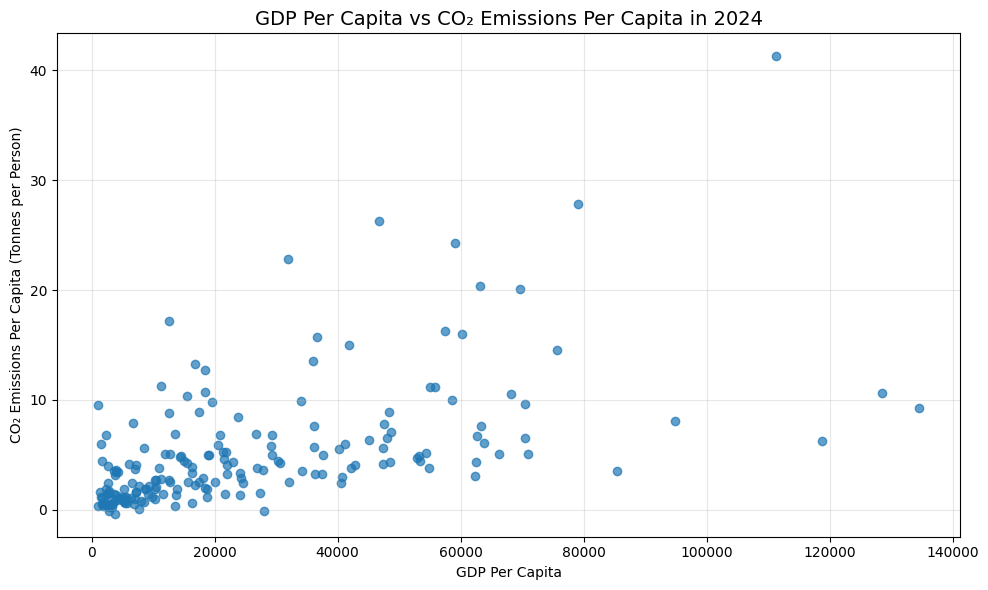

In [28]:
plt.figure(figsize=(10, 6))

plt.scatter(
    gdp_co2["GDP per capita"],
    gdp_co2[
        "Annual CO₂ emissions including land-use change per capita"
    ],
    alpha=0.7
)

plt.title(
    "GDP Per Capita vs CO₂ Emissions Per Capita in 2024",
    fontsize=14
)

plt.xlabel("GDP Per Capita")
plt.ylabel("CO₂ Emissions Per Capita (Tonnes per Person)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [29]:
# Select major countries
selected_countries = [
    "China",
    "United States",
    "India",
    "Russia",
    "Brazil",
    "Japan"
]

# Select data for 2000 and 2024
comparison_data = df_clean[
    (df_clean["Entity"].isin(selected_countries)) &
    (df_clean["Year"].isin([2000, 2024]))
].copy()

# Convert emissions to billion tonnes
comparison_data["CO2_Billion_Tonnes"] = (
    comparison_data[
        "Annual CO₂ emissions including land-use change"
    ] / 1e9
)

comparison_data[
    ["Entity", "Year", "CO2_Billion_Tonnes"]
]

,Entity,Year,CO2_Billion_Tonnes
3141,Brazil,2000,2.290019
3165,Brazil,2024,2.082678
4365,China,2000,4.278039
4389,China,2024,11.969620
10310,India,2000,1.191022
10334,India,2024,3.201024
11265,Japan,2000,1.265061
11289,Japan,2024,0.967361
18002,Russia,2000,1.495738
18026,Russia,2024,2.166402


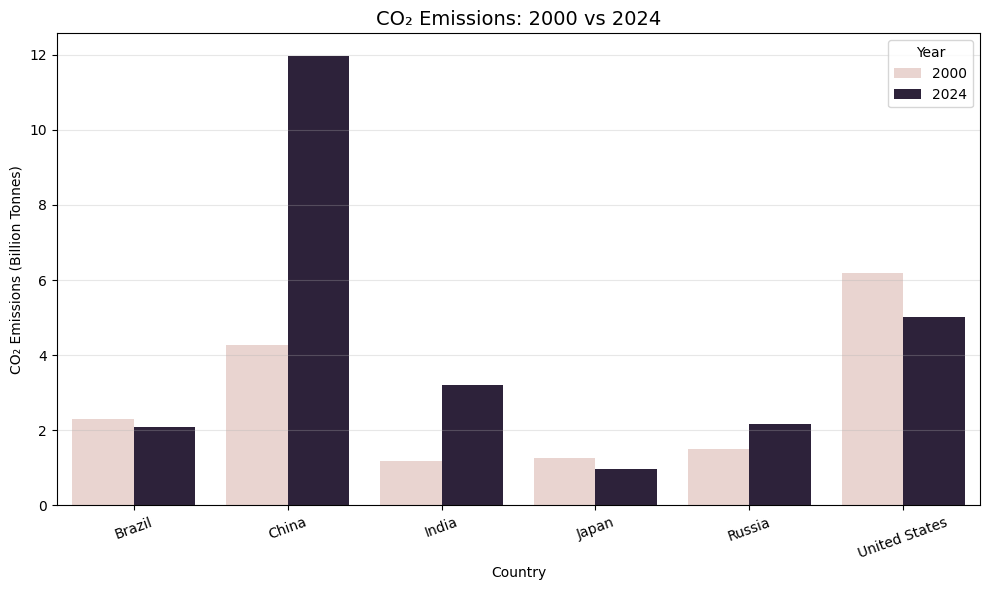

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_data,
    x="Entity",
    y="CO2_Billion_Tonnes",
    hue="Year"
)

plt.title(
    "CO₂ Emissions: 2000 vs 2024",
    fontsize=14
)

plt.xlabel("Country")
plt.ylabel("CO₂ Emissions (Billion Tonnes)")

plt.xticks(rotation=20)

plt.legend(title="Year")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()